# USO Stock Price Forecasting with Chronos-2

This notebook forecasts USO stock prices for the next 30 days using the Chronos-2 model with GPU acceleration support.

**GPU Support:**
- ✅ **MPS** (Apple Silicon M1/M2/M3/M4)
- ✅ **CUDA** (NVIDIA GPUs)
- ✅ **CPU** fallback (if no GPU available)

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Setup device (MPS for Apple Silicon, CUDA for NVIDIA GPUs, or CPU)
import torch

if torch.backends.mps.is_available():
    device = "mps"
    print("✅ Using MPS (Metal Performance Shaders) for GPU acceleration")
elif torch.cuda.is_available():
    device = "cuda"
    print("✅ Using CUDA for GPU acceleration")
else:
    device = "cpu"
    print("⚠️ Using CPU (no GPU acceleration available)")

print(f"Device: {device}")

✅ Using MPS (Metal Performance Shaders) for GPU acceleration
Device: mps


In [4]:
# Install required packages
!pip install -q "chronos-forecasting>=2.0" yfinance pandas matplotlib

In [5]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from chronos import Chronos2Pipeline

## Fetch Historical Stock Data

Downloading the past year of USO stock data.

In [6]:
# Define date range (past 1 year)
end_date = datetime(2026, 3, 16)  # Today's date
start_date = end_date - timedelta(days=365)

print(f"Fetching USO stock data from {start_date.date()} to {end_date.date()}")

# Download stock data
ticker = yf.Ticker("USO")
stock_data = ticker.history(start=start_date, end=end_date)

print(f"\\nDownloaded {len(stock_data)} trading days of data")
stock_data.head()


Fetching USO stock data from 2025-03-16 to 2026-03-16


\nDownloaded 250 trading days of data


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-03-17 00:00:00-04:00,72.980003,73.169998,72.430000,72.709999,2873700,0.0,0.0,0.0
2025-03-18 00:00:00-04:00,73.389999,73.489998,71.970001,72.209999,2739000,0.0,0.0,0.0
2025-03-19 00:00:00-04:00,72.080002,72.879997,71.930000,72.419998,1747400,0.0,0.0,0.0
2025-03-20 00:00:00-04:00,72.230003,73.800003,72.040001,73.730003,2523100,0.0,0.0,0.0
2025-03-21 00:00:00-04:00,73.389999,73.959999,73.139999,73.790001,1528800,0.0,0.0,0.0


In [7]:
# Prepare data for Chronos-2
# We'll use the closing price for forecasting

# Resample to business days and forward fill to ensure consistent frequency
stock_data_resampled = stock_data.resample('B').ffill()

context_df = pd.DataFrame({
    'timestamp': stock_data_resampled.index,
    'target': stock_data_resampled['Close'].values,
    'id': 'USO'
})

context_df = context_df.reset_index(drop=True)
print(f"Prepared {len(context_df)} data points for forecasting")
print(f"\\nDate range: {context_df['timestamp'].min()} to {context_df['timestamp'].max()}")
print(f"Price range: ${context_df['target'].min():.2f} to ${context_df['target'].max():.2f}")
context_df.tail()


Prepared 260 data points for forecasting
\nDate range: 2025-03-17 00:00:00-04:00 to 2026-03-13 00:00:00-04:00
Price range: $62.37 to $119.89


,timestamp,target,id
255,2026-03-09 00:00:00-04:00,104.330002,USO
256,2026-03-10 00:00:00-04:00,105.860001,USO
257,2026-03-11 00:00:00-04:00,108.050003,USO
258,2026-03-12 00:00:00-04:00,118.389999,USO
259,2026-03-13 00:00:00-04:00,119.889999,USO


## Load Chronos-2 Model and Generate Forecast

In [8]:
# Load Chronos-2 model with automatic device detection
print("Loading Chronos-2 model...")
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=device)
print("Model loaded successfully!")

Loading Chronos-2 model...


Model loaded successfully!


In [9]:
# Generate 30-day forecast
prediction_length = 30  # 30 trading days

print(f"Generating {prediction_length}-day forecast for USO...")

pred_df = pipeline.predict_df(
    context_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],  # 10th, 50th (median), and 90th percentiles
    id_column="id",
    timestamp_column="timestamp",
    target="target",
)

print("Forecast complete!")
pred_df.head()


Generating 30-day forecast for USO...


Forecast complete!


,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,USO,2026-03-16 00:00:00-04:00,target,118.323624,109.486938,118.323624,129.094040
1,USO,2026-03-17 00:00:00-04:00,target,117.568039,105.867233,117.568039,128.783691
2,USO,2026-03-18 00:00:00-04:00,target,117.541130,103.975113,117.541130,131.241852
3,USO,2026-03-19 00:00:00-04:00,target,117.148743,99.623070,117.148743,133.644791
4,USO,2026-03-20 00:00:00-04:00,target,116.921593,97.649628,116.921593,135.024124


## Visualize Forecast

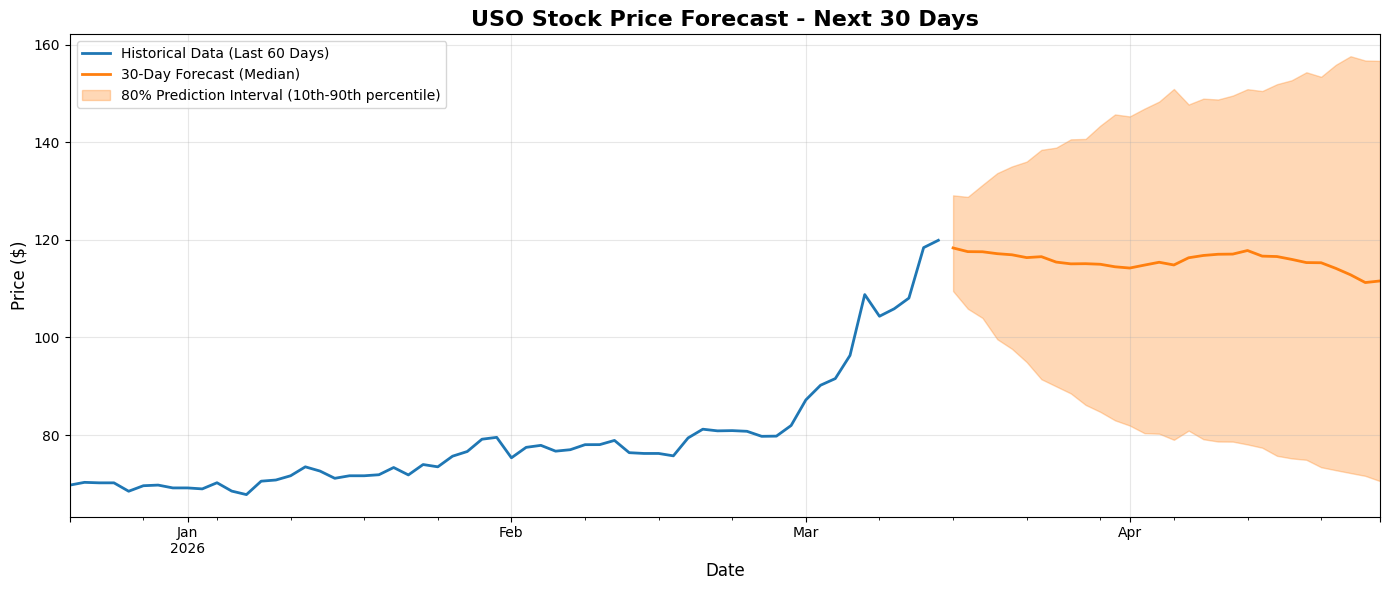

In [10]:
import matplotlib.pyplot as plt

# Show the last 60 days of historical data for context
ts_context = context_df.set_index("timestamp")["target"].tail(60)
ts_pred = pred_df.set_index("timestamp")

plt.figure(figsize=(14, 6))
ts_context.plot(label="Historical Data (Last 60 Days)", color="#1f77b4", linewidth=2)
ts_pred["predictions"].plot(label="30-Day Forecast (Median)", color="#ff7f0e", linewidth=2)

# Add prediction interval (10th to 90th percentile)
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.3,
    label="80% Prediction Interval (10th-90th percentile)",
    color="#ff7f0e",
)

plt.title("USO Stock Price Forecast - Next 30 Days", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Forecast Summary

In [11]:
# Print forecast summary
last_price = context_df['target'].iloc[-1]
forecast_median = ts_pred['predictions'].iloc[-1]
forecast_low = ts_pred['0.1'].iloc[-1]
forecast_high = ts_pred['0.9'].iloc[-1]

print("="*60)
print("USO STOCK FORECAST SUMMARY")
print("="*60)
print(f"\\nCurrent Price (as of {context_df['timestamp'].iloc[-1].date()}): ${last_price:.2f}")
print(f"\\nForecast for {pred_df['timestamp'].iloc[-1].date()} (30 days ahead):")
print(f"  Median Prediction: ${forecast_median:.2f}")
print(f"  10th Percentile:   ${forecast_low:.2f}")
print(f"  90th Percentile:   ${forecast_high:.2f}")
print(f"\\nExpected Change: ${forecast_median - last_price:.2f} ({((forecast_median - last_price) / last_price * 100):.2f}%)")
print("\\nNote: This is a probabilistic forecast. The 80% prediction interval")
print("suggests the price is likely to fall between the 10th and 90th percentiles.")
print("="*60)


USO STOCK FORECAST SUMMARY
\nCurrent Price (as of 2026-03-13): $119.89
\nForecast for 2026-04-24 (30 days ahead):
  Median Prediction: $111.56
  10th Percentile:   $70.56
  90th Percentile:   $156.64
\nExpected Change: $-8.33 (-6.95%)
\nNote: This is a probabilistic forecast. The 80% prediction interval
suggests the price is likely to fall between the 10th and 90th percentiles.


In [12]:
# Display forecast data table
forecast_table = pred_df[['timestamp', '0.1', 'predictions', '0.9']].copy()
forecast_table.columns = ['Date', 'Lower Bound (10%)', 'Median Forecast', 'Upper Bound (90%)']
forecast_table = forecast_table.set_index('Date')

print("\\nDetailed 30-Day Forecast:")
forecast_table.round(2)


\nDetailed 30-Day Forecast:


,Lower Bound (10%),Median Forecast,Upper Bound (90%)
Date,,,
2026-03-16 00:00:00-04:00,109.489998,118.320000,129.089996
2026-03-17 00:00:00-04:00,105.870003,117.570000,128.779999
2026-03-18 00:00:00-04:00,103.980003,117.540001,131.240005
2026-03-19 00:00:00-04:00,99.620003,117.150002,133.639999
2026-03-20 00:00:00-04:00,97.650002,116.919998,135.020004
2026-03-23 00:00:00-04:00,94.940002,116.349998,136.009995
2026-03-24 00:00:00-04:00,91.430000,116.529999,138.419998
2026-03-25 00:00:00-04:00,89.970001,115.430000,138.869995
2026-03-26 00:00:00-04:00,88.519997,115.059998,140.570007
